# OpenHealth Price Transparency Analysis: Professional Briefing

This notebook demonstrates professional-grade temporal analysis of healthcare pricing data, focusing on **Price Dispersion**, **Negotiation Efficiency**, and **Market Volatility**.

### Prerequisites
- Ensure OpenHealthDP server is running (`http://localhost:3001`)
- Dependencies: `pip install requests pandas matplotlib seaborn`

In [1]:
%matplotlib inline
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuration
BASE_URL = "http://localhost:3001/api/v1/transparency"
API_KEY = "AI4H2-PUBLIC-2023-BETA"

PROCEDURE_MAP = {
    "CPT:70551": "MRI Brain (without contrast)",
    "CPT:45378": "Colonoscopy",
    "DRG:871": "Sepsis (with Major CC)",
    "DRG:470": "Knee or Hip Replacement",
    "DRG:193": "Pneumonia (with Major CC)"
}

def fetch_data(pid):
    try:
        r = requests.get(BASE_URL, headers={"x-api-key": API_KEY}, params={"procedureId": pid})
        df = pd.DataFrame(r.json()["data"])
        if not df.empty:
            df['procedure_name'] = PROCEDURE_MAP.get(pid, pid)
            # Calculate Negotiation Ratio: What % of the 'Sticker Price' is actually paid?
            df['negotiation_ratio'] = (df['avg_allowed'] / df['avg_charge']) * 100
        return df
    except:
        return pd.DataFrame()

full_df = pd.concat([fetch_data(pid) for pid in PROCEDURE_MAP.keys()], ignore_index=True)

## 1. Market Coverage & Skewness Analysis
We check for **Data Density** and compare **Mean vs. Median**. If the Mean is significantly higher than the Median, the market is "Right-Skewed," meaning a few providers are charging exponentially more than the rest of the market.

### Market Skewness Report (Mean/Median Ratio)
A ratio > 1.0 indicates price outliers are pulling the average up.


source_year,2018,2019,2020,2021,2022,2023
procedure_name,,,,,,
Colonoscopy,0.99,1.00,1.01,0.99,0.99,1.01
Knee or Hip Replacement,1.06,1.06,1.05,1.07,1.12,1.12
MRI Brain (without contrast),1.01,1.01,1.01,1.01,1.01,1.01
Pneumonia (with Major CC),1.08,1.12,1.11,1.09,1.12,1.12
Sepsis (with Major CC),1.12,1.12,1.10,1.12,1.14,1.14


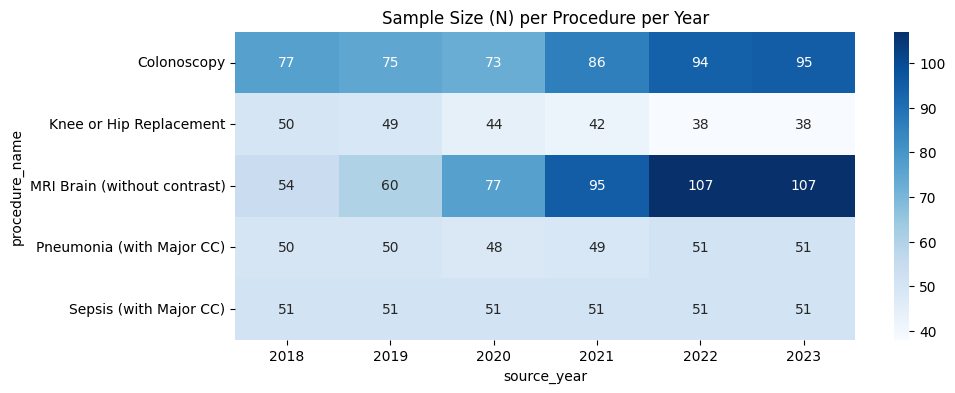

In [2]:
if not full_df.empty:
    # Coverage and Central Tendency Summary
    summary = full_df.groupby(['procedure_name', 'source_year'])['avg_allowed'].agg(['count', 'mean', 'median']).reset_index()
    summary['skew_factor'] = (summary['mean'] / summary['median']).round(2)
    
    print("### Market Skewness Report (Mean/Median Ratio)")
    print("A ratio > 1.0 indicates price outliers are pulling the average up.")
    display(summary.pivot(index='procedure_name', columns='source_year', values='skew_factor'))
    
    plt.figure(figsize=(10, 4))
    sns.heatmap(full_df.groupby(['procedure_name', 'source_year']).size().unstack(fill_value=0), annot=True, fmt="d", cmap="Blues")
    plt.title("Sample Size (N) per Procedure per Year")
    plt.show()

## 2. Temporal Volatility: The "Chaos" Index
We use the **Coefficient of Variation (CV)** ($StdDev / Mean$) to measure price dispersion. An increasing CV indicates that despite transparency laws, prices are becoming **more fragmented and less predictable**.

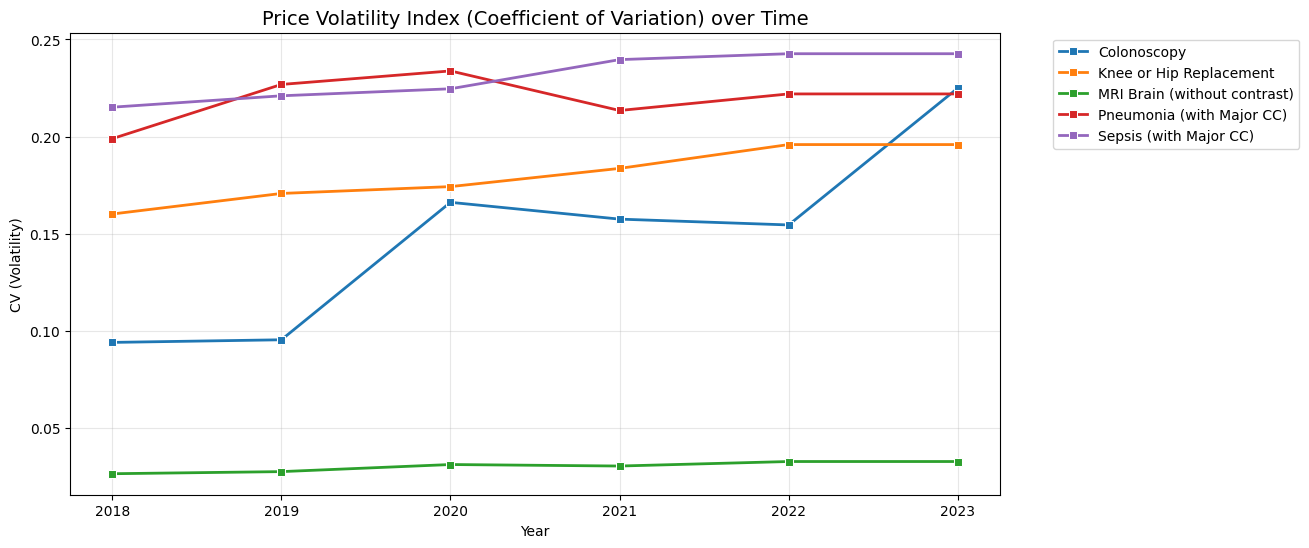

In [3]:
if not full_df.empty:
    cv_df = full_df.groupby(['procedure_name', 'source_year'])['avg_allowed'].apply(lambda x: x.std() / x.mean()).reset_index()
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=cv_df, x='source_year', y='avg_allowed', hue='procedure_name', marker='s', linewidth=2)
    plt.title("Price Volatility Index (Coefficient of Variation) over Time", fontsize=14)
    plt.ylabel("CV (Volatility)")
    plt.xlabel("Year")
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

## 3. Negotiation Efficiency Trend
This plot shows the **Negotiated Amount as a % of Gross Charge**. A declining trend suggests that hospitals are inflating "Sticker Prices" while negotiated rates remain stable—a practice known as **Price Masking**.

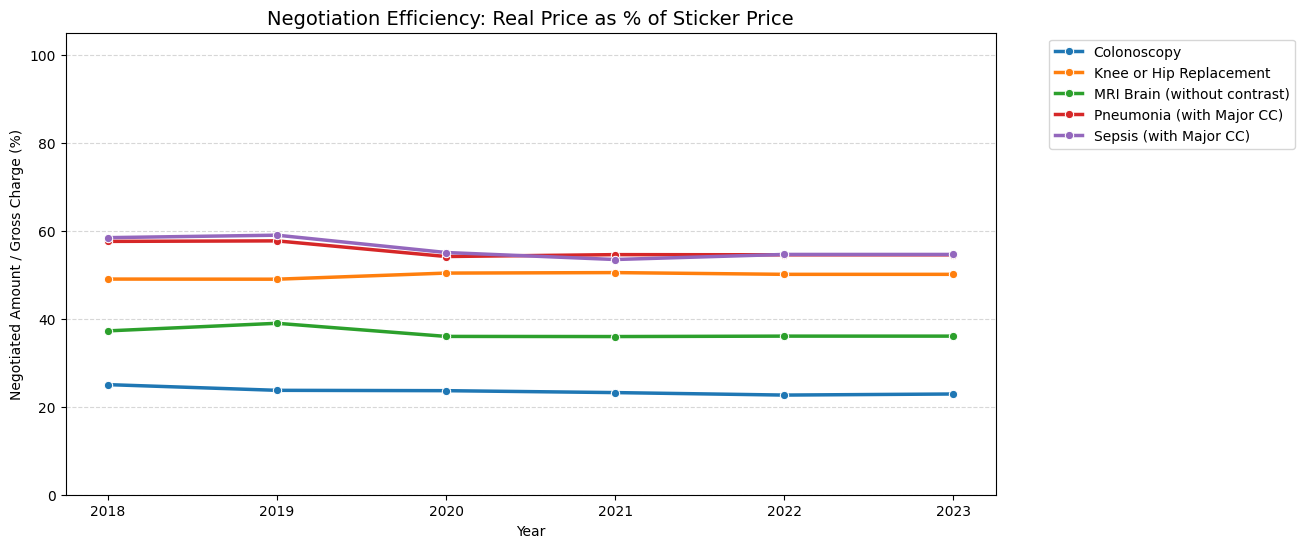

In [4]:
if not full_df.empty:
    ratio_trend = full_df.groupby(['procedure_name', 'source_year'])['negotiation_ratio'].mean().reset_index()
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=ratio_trend, x='source_year', y='negotiation_ratio', hue='procedure_name', marker='o', linewidth=2.5)
    plt.title("Negotiation Efficiency: Real Price as % of Sticker Price", fontsize=14)
    plt.ylabel("Negotiated Amount / Gross Charge (%)")
    plt.xlabel("Year")
    plt.ylim(0, 105)
    plt.grid(True, axis='y', ls='--', alpha=0.5)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

## 4. Price Dispersion: MRI Brain (10th/90th Percentiles)
Finally, we look at the raw spread for a single procedure. The gap between the 10th and 90th percentile represents the **"Transparency Opportunity"**—the potential savings a patient could realize by shopping around.

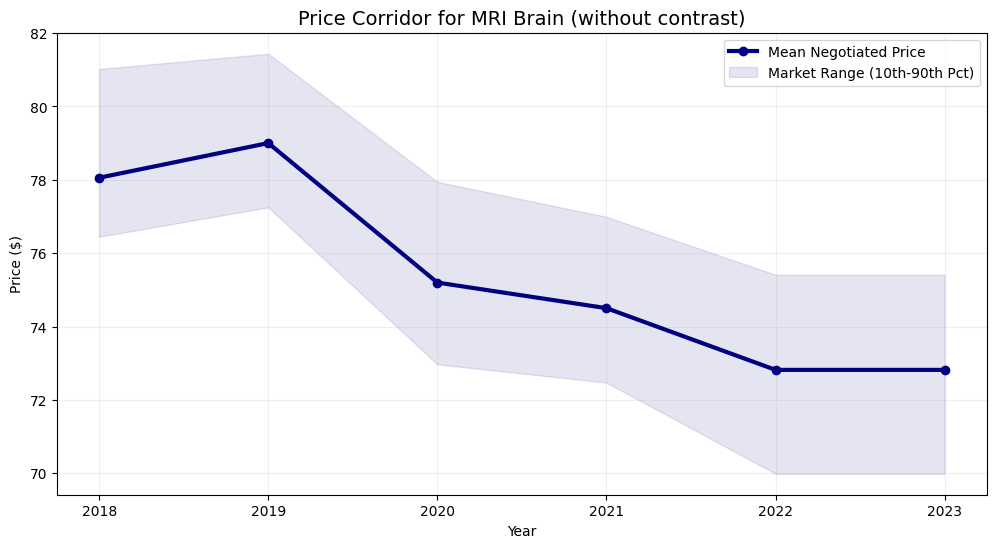

In [5]:
pid = "CPT:70551"
df_single = full_df[full_df['procedure_id'] == pid]
if not df_single.empty:
    stats = df_single.groupby('source_year')['avg_allowed'].agg(['mean', lambda x: x.quantile(0.10), lambda x: x.quantile(0.90)]).reset_index()
    stats.columns = ['Year', 'Mean', 'P10', 'P90']
    
    plt.figure(figsize=(12, 6))
    plt.plot(stats['Year'], stats['Mean'], marker='o', color='navy', label='Mean Negotiated Price', linewidth=3)
    plt.fill_between(stats['Year'], stats['P10'], stats['P90'], color='navy', alpha=0.1, label='Market Range (10th-90th Pct)')
    plt.title(f"Price Corridor for {PROCEDURE_MAP[pid]}", fontsize=14)
    plt.ylabel("Price ($)")
    plt.xlabel("Year")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()